In [1]:
import os, sys
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
import torch
from skimage.transform import resize
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

In [2]:
PROJECT_ROOT = "/share/castor/home/e2406751/Superresolution-TIR"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
 
from scripts.utils.dataset import SRDataset
from scripts.models.edsr import EDSRModule
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
import wandb
 
# Replace <run_id> with your actual run ID e.g. xmujl7dh
api   = wandb.Api()
art   = api.artifact("ogalloethel-university-of-south-brittany/TIR_sisr/model-s1dxac6f:best")
local = art.download("/tmp/ckpt")
ckpt_path = next(os.path.join(local, f) for f in os.listdir(local) if f.endswith(".ckpt"))
print(f"Checkpoint: {ckpt_path}")
 
model = EDSRModule.load_from_checkpoint(ckpt_path, map_location=device)
model.eval()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /share/home/e2406751/.netrc.
wandb:   1 of 1 files downloaded.  
/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of 

Checkpoint: /tmp/ckpt/model.ckpt
[INFO] Loading pretrained weights: /share/home/e2406751/Superresolution-TIR/data/pretrained/EDSR_baseline_x4.pth
[INFO] Matched 68 / 74 layers


EDSRModule(
  (body): EDSR(
    (conv_first): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (body): Sequential(
      (0): ResidualBlockNoBN(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
      )
      (1): ResidualBlockNoBN(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
      )
      (2): ResidualBlockNoBN(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (relu): ReLU(inplace=True)
      )
      (3): ResidualBlockNoBN(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(64, 64, ker

In [4]:
with open("data/full_metadata.json") as f:
    all_meta = json.load(f)
 
metadata = pd.DataFrame(all_meta)
test_df  = metadata[metadata["split"] == "test"].reset_index(drop=True)
print(f"Test patches: {len(test_df)}")
 
ds = SRDataset(test_df, mean=model.hparams.mean, std=model.hparams.std)

Test patches: 4


In [33]:
# Change PATCH_IDX to inspect different patches
PATCH_IDX = 0
print(f"Patch: {test_df.iloc[PATCH_IDX]['patch_id']}")
 
lr_t, hr_t, mask_t = ds[PATCH_IDX]
 
with torch.no_grad():
    sr_t = model(lr_t.unsqueeze(0).to(device))
 
# Denormalize everything to °C
sr = model.denormalize(sr_t).squeeze().cpu().numpy()
hr = model.denormalize(hr_t.unsqueeze(0)).squeeze().numpy()
lr = model.denormalize(lr_t.unsqueeze(0)).squeeze().numpy()
mk = mask_t.squeeze().numpy() > 0.5
 
# Resize mask to LR resolution for LR display
lr_mask = resize(mk, lr.shape, order=0, preserve_range=True) > 0.5
 
# Mask nodata regions
hr_disp = np.where(mk,      hr, np.nan)
sr_disp = np.where(mk,      sr, np.nan)
lr_disp = np.where(lr_mask, lr, np.nan)
 
# Metrics on valid region
sr_t_den   = model.denormalize(sr_t)
hr_t_den   = model.denormalize(hr_t.unsqueeze(0).to(device))
mask_t_dev = mask_t.unsqueeze(0).to(device)
 
sr_crop, mask_crop = model.crop_to_valid_bbox(sr_t_den, mask_t_dev)
hr_crop, _         = model.crop_to_valid_bbox(hr_t_den, mask_t_dev)
 
device = sr_crop.device  # or just `device` from your script

psnr_metric = PeakSignalNoiseRatio(data_range=60.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=60.0).to(device)

psnr_val = psnr_metric(sr_crop * mask_crop, hr_crop * mask_crop).item()
ssim_val = ssim_metric(sr_crop, hr_crop).item()
mae_val  = float(np.abs(sr_disp[mk] - hr_disp[mk]).mean())
 
print(f"PSNR : {psnr_val:.2f} dB")
print(f"SSIM : {ssim_val:.3f}")
print(f"MAE  : {mae_val:.4f} °C")

Patch: PDR_2023_2.tif
PSNR : 26.56 dB
SSIM : 0.720
MAE  : 2.5630 °C


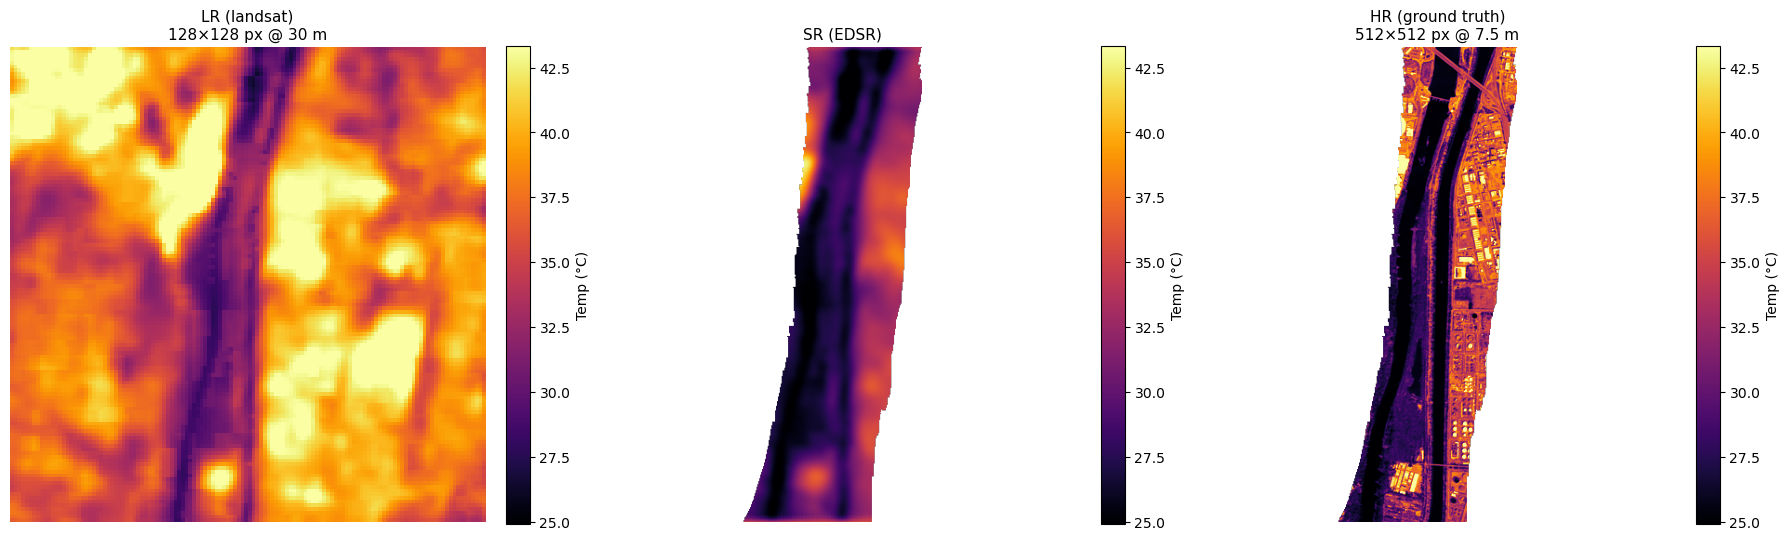

In [34]:
# vmin and vmax from HR
vmin = np.nanpercentile(hr_disp, 2)
vmax = np.nanpercentile(hr_disp, 98)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# LR: show full scene
lr_disp = lr  # no masking needed

# SR: can show full model output
# sr_disp = sr  # optionally mask to HR region if you want
sr_disp = np.where(mk,      sr, np.nan)

# HR: can mask invalid pixels if you like
hr_disp = np.where(mk, hr, np.nan)

panels = [
    (lr_disp, f"LR (landsat)\n{lr.shape[1]}×{lr.shape[0]} px @ 30 m"),
    (sr_disp, f"SR (EDSR)"),
    (hr_disp, f"HR (ground truth)\n{hr.shape[1]}×{hr.shape[0]} px @ 7.5 m"),
]
 
for ax, (img, title) in zip(axes, panels):
    im = ax.imshow(img, cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Temp (°C)")
 
plt.tight_layout()
plt.show()
 

edeges not preserved??

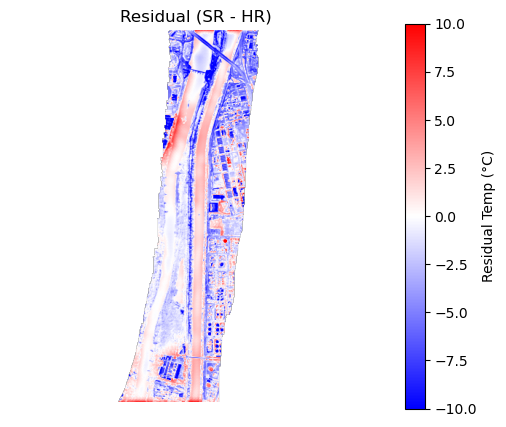

In [42]:
residual = sr_disp - hr_disp

plt.figure(figsize=(6, 5))
plt.imshow(residual, cmap="bwr", vmin=-10, vmax=10)
plt.colorbar(label="Residual Temp (°C)")
plt.title("Residual (SR - HR)", fontsize=12)
plt.axis("off")
plt.show()

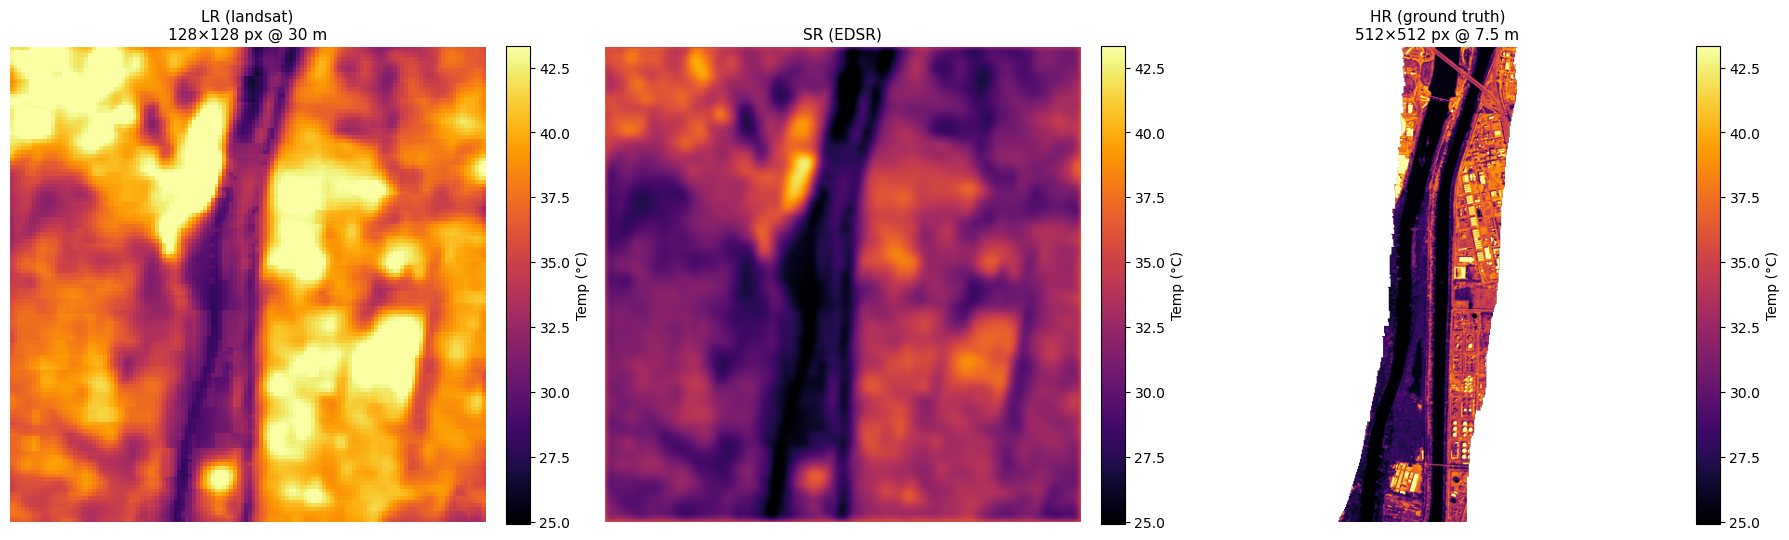

In [ ]:
# Shared colour scale anchored to HR valid pixels — critical so differences
# between panels are visually meaningful and not just colour scale artefacts
vmin = np.nanpercentile(hr_disp, 2)
vmax = np.nanpercentile(hr_disp, 98)
 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# LR: show full scene
lr_disp = lr  # no masking needed

# SR: can show full model output
sr_disp = sr  # optionally mask to HR region if you want
# sr_disp = np.where(mk,      sr, np.nan)

# HR: can mask invalid pixels if you like
hr_disp = np.where(mk, hr, np.nan)

residual = sr_disp - hr_disp

panels = [
    (lr_disp, f"LR (landsat)\n{lr.shape[1]}×{lr.shape[0]} px @ 30 m"),
    (sr_disp, f"SR (EDSR)"),
    (hr_disp, f"HR (ground truth)\n{hr.shape[1]}×{hr.shape[0]} px @ 7.5 m"),
    (residual, f"Residual (SR - HR)")
]
 
for ax, (img, title) in zip(axes, panels):
    im = ax.imshow(img, cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Temp (°C)")
 

plt.tight_layout()
plt.show()
 

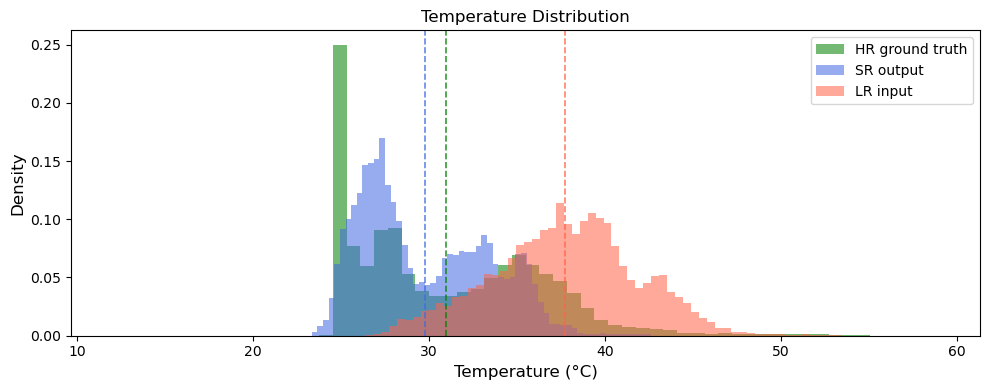

In [39]:
# A blurry model will have SR std << HR std — distribution too narrow
# A good model will have SR std ≈ HR std and similar shape
hr_valid = hr_disp[mk].flatten()
sr_valid = sr_disp[mk].flatten()
# lr_valid = lr_disp[lr_mask].flatten()
lr_valid = lr_disp.flatten()  # no masking needed
 
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hr_valid, bins=60, alpha=0.55, color="green",     label="HR ground truth", density=True)
ax.hist(sr_valid, bins=60, alpha=0.55, color="royalblue", label="SR output",       density=True)
ax.hist(lr_valid, bins=60, alpha=0.55, color="tomato",    label="LR input",        density=True)
 
# Vertical mean lines
for val, color in [(hr_valid.mean(), "green"),
                   (sr_valid.mean(), "royalblue"),
                   (lr_valid.mean(), "tomato")]:
    ax.axvline(val, color=color, linestyle="--", lw=1.2, alpha=0.8)
 
ax.set_xlabel("Temperature (°C)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Temperature Distribution", fontsize=12)
ax.legend(fontsize=10)
 
# Std annotation — key diagnostic for blurriness
# textstr = (f"HR  std: {hr_valid.std():.3f} °C\n"
#            f"SR  std: {sr_valid.std():.3f} °C\n"
#            f"LR  std: {lr_valid.std():.3f} °C")
# ax.text(0.98, 0.97, textstr, transform=ax.transAxes,
#         fontsize=9, va="top", ha="right",
#         bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
plt.tight_layout()
plt.show()

In [ ]:
# Perfect model → points on white diagonal
# Blurry model  → points cluster horizontally around mean (low variance in SR)
# Bias          → regression line offset from diagonal
t_min = min(sr_valid.min(), hr_valid.min())
t_max = max(sr_valid.max(), hr_valid.max())
 
fig, ax = plt.subplots(figsize=(7, 7))
 
# 2D histogram — faster than scatter, log scale keeps sparse regions visible
h, xedges, yedges = np.histogram2d(hr_valid, sr_valid, bins=100)
im = ax.imshow(
    h.T, origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect="auto",
    norm=mcolors.LogNorm(vmin=1),
    cmap="viridis",
)
plt.colorbar(im, ax=ax, label="Pixel count (log scale)")
 
# Perfect prediction line
ax.plot([t_min, t_max], [t_min, t_max], "w--", lw=1.5, label="Perfect prediction")
 
# Regression line — reveals systematic bias
coeffs = np.polyfit(hr_valid, sr_valid, 1)
x_line = np.array([t_min, t_max])
ax.plot(x_line, np.polyval(coeffs, x_line), "r-", lw=1.5,
        label=f"Fit: y={coeffs[0]:.2f}x+{coeffs[1]:.2f}")
 
ax.set_xlabel("HR Temperature (°C)", fontsize=12)
ax.set_ylabel("SR Temperature (°C)", fontsize=12)
ax.set_title(f"Pixel-wise SR vs HR ", fontsize=12)
ax.legend(fontsize=10)
 
r    = np.corrcoef(hr_valid, sr_valid)[0, 1]
bias = (sr_valid - hr_valid).mean()
textstr = (f"Pearson r : {r:.4f}\n"
           f"Bias      : {bias:+.4f} °C\n"
           f"MAE       : {mae_val:.4f} °C")
ax.text(0.03, 0.97, textstr, transform=ax.transAxes,
        fontsize=9, va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
 
plt.tight_layout()
plt.show()
 

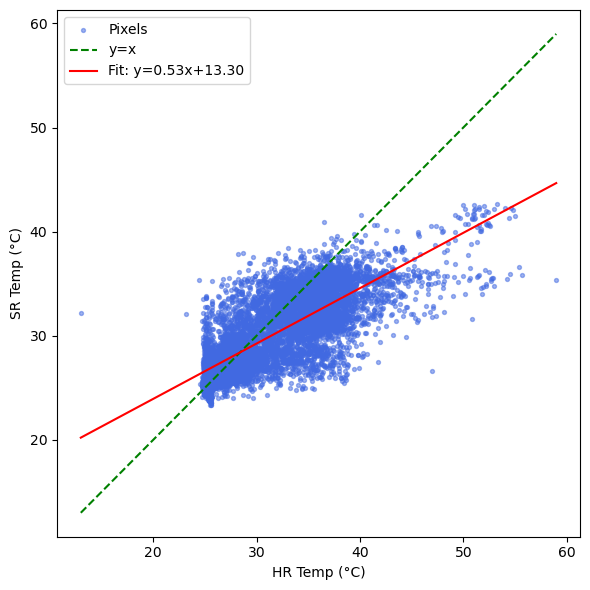

In [43]:
# Flatten valid pixels
hr_valid = hr_disp[mk].flatten()
sr_valid = sr_disp[mk].flatten()

# Sample pixels for plotting
num_samples = min(len(hr_valid), 10000)
indices = np.random.choice(len(hr_valid), num_samples, replace=False)
hr_sample = hr_valid[indices]
sr_sample = sr_valid[indices]

# Scatter plot
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(hr_sample, sr_sample, s=8, alpha=0.5, color='royalblue', label='Pixels')

# Ideal prediction line
t_min = min(hr_sample.min(), sr_sample.min())
t_max = max(hr_sample.max(), sr_sample.max())
ax.plot([t_min, t_max], [t_min, t_max], 'g--', lw=1.5, label='y=x')

# Regression line
coeffs = np.polyfit(hr_sample, sr_sample, 1)
x_line = np.array([t_min, t_max])
ax.plot(x_line, np.polyval(coeffs, x_line), 'r-', lw=1.5, label=f'Fit: y={coeffs[0]:.2f}x+{coeffs[1]:.2f}')


ax.set_xlabel("HR Temp (°C)")
ax.set_ylabel("SR Temp (°C)")
ax.legend()
plt.tight_layout()
plt.show()

In [47]:
with rasterio.open('/share/home/e2406751/Superresolution-TIR/results/SR_images/SR_PDR_2023.tif') as src:
    sr_full = src.read(1)

# shape
print(f"SR full image shape: {sr_full.shape}")
# resolution
print(f"SR full image resolution: {src.res[0]} m/px")

SR full image shape: (6367, 1396)
SR full image resolution: 7.5 m/px


In [48]:
# checking resolution of one sr patch
print(f"SR patch resolution: {src.res[0] * (hr.shape[1] / sr.shape[1]):.2f} m/px")

SR patch resolution: 7.50 m/px


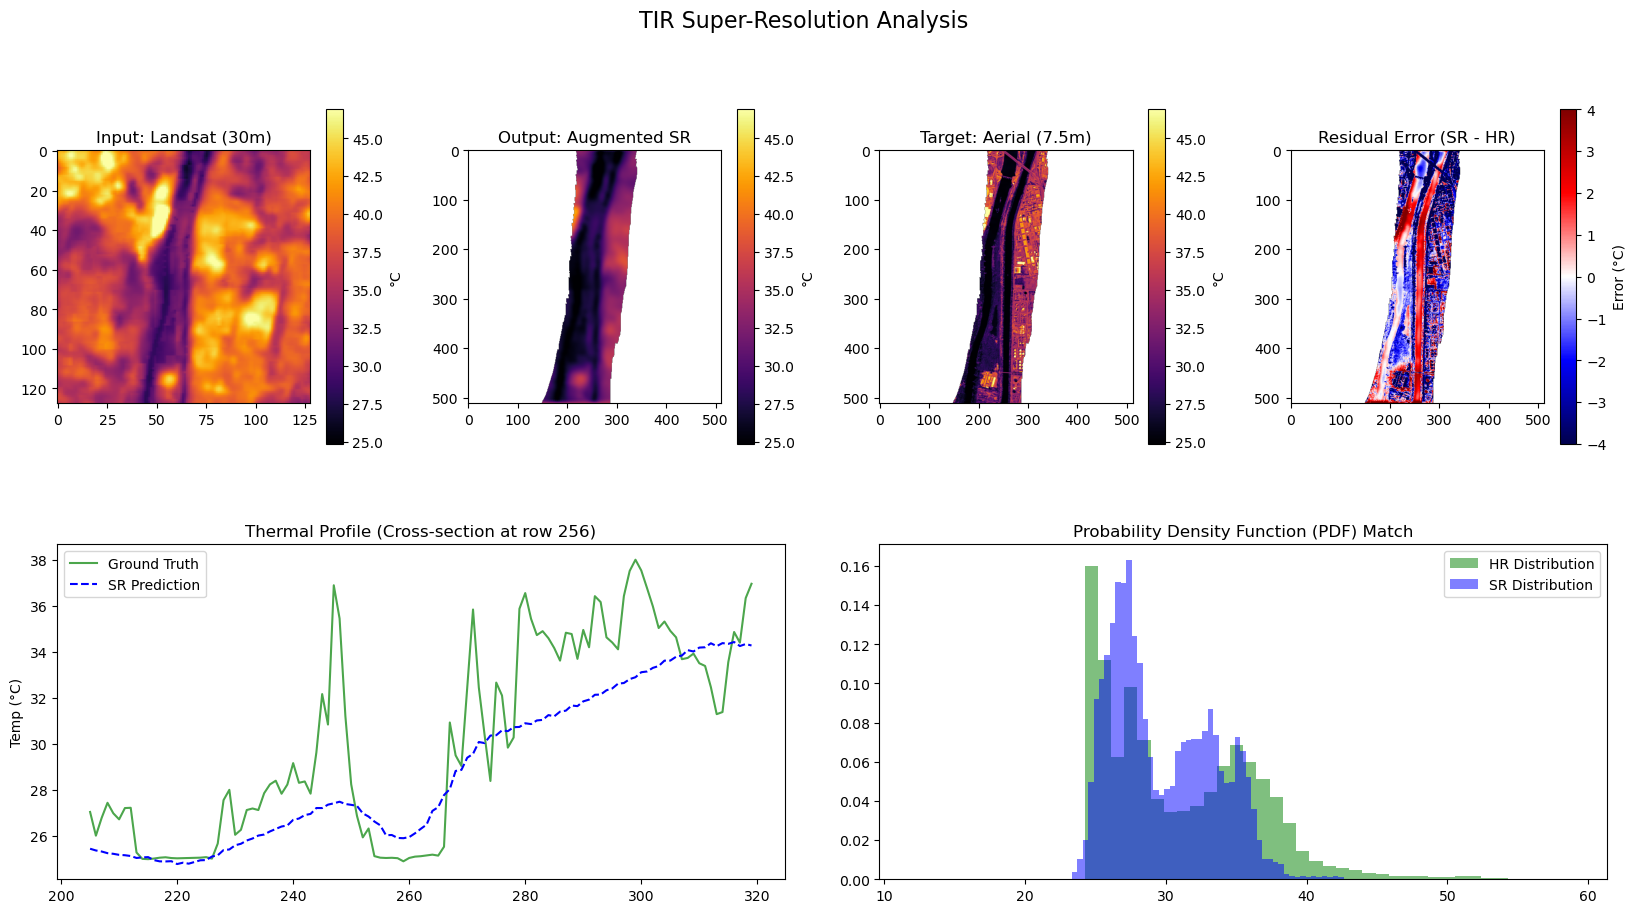

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scientific_comparison(lr, sr, hr, mask, title_suffix=""):
    # 1. Mask the data for fair comparison
    sr_m = np.where(mask, sr, np.nan)
    hr_m = np.where(mask, hr, np.nan)
    residual = sr_m - hr_m
    
    # 2. Set consistent thermal scales
    vmin, vmax = np.nanpercentile(hr_m, 1), np.nanpercentile(hr_m, 99)
    
    fig = plt.figure(figsize=(20, 10))
    grid = plt.GridSpec(2, 4, wspace=0.3, hspace=0.3)

    # --- TOP ROW: SPATIAL MAPS ---
    ax_lr = fig.add_subplot(grid[0, 0])
    im0 = ax_lr.imshow(lr, cmap='inferno', vmin=vmin, vmax=vmax)
    ax_lr.set_title("Input: Landsat (30m)")
    plt.colorbar(im0, ax=ax_lr, label="°C")

    ax_sr = fig.add_subplot(grid[0, 1])
    im1 = ax_sr.imshow(sr_m, cmap='inferno', vmin=vmin, vmax=vmax)
    ax_sr.set_title("Output: Augmented SR")
    plt.colorbar(im1, ax=ax_sr, label="°C")

    ax_hr = fig.add_subplot(grid[0, 2])
    im2 = ax_hr.imshow(hr_m, cmap='inferno', vmin=vmin, vmax=vmax)
    ax_hr.set_title("Target: Aerial (7.5m)")
    plt.colorbar(im2, ax=ax_hr, label="°C")

    # --- THE RESIDUAL (ERROR MAP) ---
    ax_res = fig.add_subplot(grid[0, 3])
    # seismic centers at 0 (white). Red = SR too hot, Blue = SR too cold.
    im3 = ax_res.imshow(residual, cmap='seismic', vmin=-4, vmax=4)
    ax_res.set_title("Residual Error (SR - HR)")
    plt.colorbar(im3, ax=ax_res, label="Error (°C)")

    # --- BOTTOM ROW: STATISTICAL TRUTH ---
    # Thermal Profile (Center Cross-section)
    ax_prof = fig.add_subplot(grid[1, :2])
    mid = hr.shape[0] // 2
    ax_prof.plot(hr_m[mid, :], color='green', label='Ground Truth', alpha=0.7)
    ax_prof.plot(sr_m[mid, :], color='blue', label='SR Prediction', linestyle='--')
    ax_prof.set_title(f"Thermal Profile (Cross-section at row {mid})")
    ax_prof.set_ylabel("Temp (°C)")
    ax_prof.legend()

    # Histogram Comparison
    ax_hist = fig.add_subplot(grid[1, 2:])
    ax_hist.hist(hr_m[~np.isnan(hr_m)], bins=50, alpha=0.5, color='green', label='HR Distribution', density=True)
    ax_hist.hist(sr_m[~np.isnan(sr_m)], bins=50, alpha=0.5, color='blue', label='SR Distribution', density=True)
    ax_hist.set_title("Probability Density Function (PDF) Match")
    ax_hist.legend()

    plt.suptitle(f"TIR Super-Resolution Analysis {title_suffix}", fontsize=16)
    plt.show()

# Run it
plot_scientific_comparison(lr, sr, hr, mk)